In [1]:
import json
import argparse
import torch
from torch import nn
import wandb
from matplotlib import pyplot as plt
from src.data_loader import get_data_loaders
from src.loss import DifferentiableWeightedRadialFrequencyLoss
from src.model_diffusion import DiffusionModel
from src.model import Unet
from src.trainer import train_diffusion_model, train_diffusion_model_multisteps
from src.utils import count_parameters
from src.diffusion_utils import predict_start_from_noise, ddim_x0_estimate
from torch import optim
import numpy as np

device = 'cuda'

In [2]:
from sda.mcs import KolmogorovFlow

%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=1

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=1


In [3]:
data_params = {
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "dataset_name": "KolmogorovFlow",
        "resolution": 64,
        "sequence_length": [3, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 50,
        "batch_size": 100
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [4]:
import torch

# ---------- Utilities ----------

def _fft_magnitude(x, take_log=True):
    """Compute magnitude of 2D FFT for tensor (N,C,H,W)."""
    fft = torch.fft.fft2(x)
    mag = torch.abs(fft)
    if take_log:
        mag = torch.log1p(mag)
    return mag


def _radial_average(psd2d):
    """Compute radially averaged power spectrum for (H,W) or (N,C,H,W)."""
    if psd2d.ndim == 4:
        N, C, H, W = psd2d.shape
        cy, cx = H // 2, W // 2
        y, x = torch.meshgrid(torch.arange(H, device=psd2d.device),
                              torch.arange(W, device=psd2d.device),
                              indexing='ij')
        r = torch.sqrt((x - cx)**2 + (y - cy)**2).to(torch.int64)
        nbins = int(r.max()) + 1
        radial_profiles = []
        for n in range(N):
            ch_profiles = []
            for c in range(C):
                psd_flat = psd2d[n, c].flatten()
                r_flat = r.flatten()
                tbin = torch.bincount(r_flat, weights=psd_flat, minlength=nbins)
                nr = torch.bincount(r_flat, minlength=nbins).float()
                radial = tbin / (nr + 1e-8)
                ch_profiles.append(radial)
            radial_profiles.append(torch.stack(ch_profiles))
        return torch.stack(radial_profiles)  # (N,C,K)
    else:
        raise ValueError("Expected (N,C,H,W)")


def _cov_torch(x, eps=1e-6):
    """Covariance along batch dimension."""
    x = x - x.mean(dim=0, keepdim=True)
    N = x.shape[0]
    cov = (x.T @ x) / (N - 1)
    cov += torch.eye(cov.shape[0], device=x.device, dtype=x.dtype) * eps
    return cov


def _sqrtm_symmetric_torch(mat):
    """Matrix square root via eigen-decomposition (symmetric PSD case)."""
    eigvals, eigvecs = torch.linalg.eigh(mat)
    eigvals = torch.clamp(eigvals, min=0)
    sqrt_eigvals = torch.sqrt(eigvals)
    return (eigvecs * sqrt_eigvals.unsqueeze(0)) @ eigvecs.T


def frechet_distance_torch(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """
    Compute squared Fréchet distance between two Gaussians.
    """
    diff = mu1 - mu2
    diff_sq = diff.dot(diff)

    # product sqrt: (sigma1 * sigma2)^(1/2)
    cov_prod = sigma1 @ sigma2
    covmean = _sqrtm_symmetric_torch(cov_prod)

    trace_term = torch.trace(sigma1) + torch.trace(sigma2) - 2 * torch.trace(covmean)
    trace_term = torch.clamp(trace_term, min=0)  # avoid tiny negatives
    return diff_sq + trace_term


# ---------- Metrics ----------

def spectral_psd_error(pred, true):
    """
    Mean relative error of radially averaged power spectra.
    pred, true: (N,C,H,W)
    """
    Fp = torch.fft.fftshift(torch.fft.fft2(pred))
    Ft = torch.fft.fftshift(torch.fft.fft2(true))
    psd_pred = torch.abs(Fp) ** 2
    psd_true = torch.abs(Ft) ** 2

    rad_pred = _radial_average(psd_pred)
    rad_true = _radial_average(psd_true)

    rel_err = ((rad_pred - rad_true) ** 2) / (rad_true ** 2 + 1e-8)
    return rel_err.mean()


def spectral_coherence(pred, true):
    """
    Global spectral coherence between predicted and true fields.
    pred, true: (N,C,H,W)
    Returns: scalar in [0,1].
    """
    Fp = torch.fft.fft2(pred)
    Ft = torch.fft.fft2(true)
    num = torch.abs((Fp * Ft.conj()).mean(dim=(-2, -1)))
    denom = torch.sqrt((torch.abs(Fp) ** 2).mean(dim=(-2, -1)) *
                       (torch.abs(Ft) ** 2).mean(dim=(-2, -1)))
    coherence = (num / (denom + 1e-8)).mean()
    return coherence


def fsd_torch_full(real, gen, take_log=True, eps=1e-6, return_sqrt=False):

    N, C, H, W = real.shape
    real_mag = _fft_magnitude(real, take_log)
    gen_mag = _fft_magnitude(gen, take_log)

    # Flatten spatial dims and channels per sample
    Xr = real_mag.view(N, -1)
    Xg = gen_mag.view(N, -1)

    mu_r = Xr.mean(dim=0)
    mu_g = Xg.mean(dim=0)
    cov_r = _cov_torch(Xr, eps)
    cov_g = _cov_torch(Xg, eps)

    fsd_sq = frechet_distance_torch(mu_r, cov_r, mu_g, cov_g)
    return torch.sqrt(fsd_sq) if return_sqrt else fsd_sq

def _radial_average_vectorized(psd2d):
    """
    Vectorized version: no loop over N.
    psd2d: (N, C, H, W)
    Returns: (N, C*K) flattened radial profiles
    """
    N, C, H, W = psd2d.shape
    cy, cx = H // 2, W // 2
    y, x = torch.meshgrid(torch.arange(H, device=psd2d.device),
                          torch.arange(W, device=psd2d.device),
                          indexing='ij')
    r = torch.sqrt((x - cx)**2 + (y - cy)**2).long()
    
    # max radius
    nbins = int(r.max()) + 1
    
    # Flatten spatial dims: (N, C, H*W)
    psd_flat = psd2d.view(N, C, -1)
    r_flat = r.flatten() # (H*W)
    
    # Scatter add to compute sums per bin
    # We use a trick: extend bins to (N, C, nbins)
    # This part can be memory intensive if N is huge, but usually fine
    
    # Pre-calculate bin counts for denominator (independent of batch)
    nr = torch.bincount(r_flat, minlength=nbins).float()
    nr[nr == 0] = 1.0 # avoid div by zero
    
    # Accumulate
    # Create an output tensor (N, C, nbins)
    radial_profiles = torch.zeros((N, C, nbins), device=psd2d.device, dtype=psd2d.dtype)
    
    # We need to loop over bins or use scatter_add. 
    # Since nbins is small (~H/2), a loop over radius is actually faster 
    # than scatter_add on large batches due to atomic overhead.
    for i in range(nbins):
        # Mask for current radius
        mask = (r_flat == i)
        if mask.any():
            # Mean over the ring
            val = psd_flat[..., mask].mean(dim=-1)
            radial_profiles[..., i] = val

    # Flatten (N, C*K)
    return radial_profiles.view(N, -1)

def fsd_torch_radial(real, gen, take_log=True, eps=1e-6):
    """
    Computes FSD based on 1D Radial Power Spectra.
    Huge speedup: O((H/2)^3) instead of O((HW)^3).
    """
    real_mag = _fft_magnitude(real, take_log)**2 # Use Power (mag^2) or Mag
    gen_mag = _fft_magnitude(gen, take_log)**2
    
    # Get profiles (N, D_small)
    Xr = _radial_average_vectorized(real_mag)
    Xg = _radial_average_vectorized(gen_mag)
    
    mu_r = Xr.mean(dim=0)
    mu_g = Xg.mean(dim=0)
    cov_r = _cov_torch(Xr, eps)
    cov_g = _cov_torch(Xg, eps)

    fsd_sq = frechet_distance_torch(mu_r, cov_r, mu_g, cov_g)
    return fsd_sq


# ---------- Combined evaluator ----------

def spectral_metrics(pred, true):
    """
    Compute spectral correctness metrics between predicted and ground-truth fields.
    Input: (N,C,H,W) tensors
    Output: dict with PSD error, coherence, FSD
    """
    return {
        "psd_error": spectral_psd_error(pred, true),
        "coherence": spectral_coherence(pred, true),
        "fsd": fsd_torch_full(true, pred, return_sqrt=False)
    }


In [5]:
import torch

def run_model(model, x):
    """Wrapper for forward pass."""
    if isinstance(model, DiffusionModel):
        return model(x)
    else:
        return model(x, time=None)

def evaluate_models(models, m_eval, traj_loader, device, rollout_steps=30, with_meta_eval=False):
    """
    Compare:
    - plain model rollouts vs. m_eval rollouts (eval_distances)
    - plain model rollouts vs. model(eval(model)) rollouts (meta_distances)

    Args:
        models (dict): { "name": model } dictionary of models to evaluate
        m_eval (nn.Module): evaluator model
        traj_loader (DataLoader): trajectory loader
        device (torch.device): device to run on
        rollout_steps (int): number of rollout steps

    Returns:
        dict with:
            predictions[name]: list of model rollout tensors
            meta_eval[name]: list of model(eval(model)) rollout tensors
            eval_distances[name]: list of distances vs m_eval
            meta_distances[name]: list of distances vs meta trajectory
    """
    # Put all models in eval mode
    for model in list(models.values()) + [m_eval]:
        model.eval()

    if with_meta_eval :
        meta_eval = {name: [] for name in models}
        meta_distances = {name: [] for name in models}
        meta_preds = {name: [] for name in models}
    
    eval_distances = {name: [] for name in models}

    with torch.no_grad():
        sample = next(iter(traj_loader))

        data = sample["data"].to(device)
        print("Input shape:", data.shape)

        conditioning_frame = data[:, 0]

        # Initialize plain and meta trajectories
        preds = {name: run_model(model, conditioning_frame) for name, model in models.items()}
        predictions = {name: [preds[name]] for name, model in models.items()}
        

        # Store step 0
        for name, model in models.items():    
            pred_eval = run_model(m_eval, conditioning_frame)
            if with_meta_eval:
                meta_preds[name].append(pred_eval)
            eval_distances[name].append(torch.mean((pred_eval - preds[name]) ** 2))

        # Rollout
        for t in range(rollout_steps):
            for name, model in models.items():

                eval_pred_on_model = run_model(m_eval, preds[name])

                if with_meta_eval:
                    model_pred_on_eval = run_model(model, meta_preds[name])
                    meta_preds[name] = eval_pred_on_model
                
                # plain model step
                preds[name] = run_model(model, preds[name])
                predictions[name].append(preds[name])
                
                # distance vs m_eval
                eval_distances[name].append(torch.mean((eval_pred_on_model - preds[name]) ** 2))
                # distance vs meta trajectory
                if with_meta_eval:
                    meta_distances[name].append(torch.mean((model_pred_on_eval - preds[name]) ** 2))

    if with_meta_eval:
        return {
            "predictions": preds,
            "meta_eval": meta_eval,
            "eval_distances": eval_distances,
            "meta_distances": meta_distances,
        }
    return {"predictions": predictions,
            "eval_distances": eval_distances,
            "data": data}

In [8]:
m_eval_1 = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_12/Model_E2460.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval_1.load_state_dict(checkpoint)

m_eval_1.to(device)


m_eval = Unet(
            dim=64,
            channels= 2,
            dim_mults=(1,1,1),
            use_convnext=True,
            convnext_mult=1,
            with_time_emb=False)

checkpoint = torch.load("/mnt/SSD2/constantin/autoreg-pde-diffusion-old/runs/2D_Kolmo_rozet_upsampled/res_64_ts_1_dim_64_framesPerTs_1_unet-periodicconv-m2_13/Model_E900.pth", map_location=torch.device('cpu'))['stateDictDecoder']
m_eval.load_state_dict(checkpoint)

m_eval.to(device)

m3=  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_189/best_model.pth')
m3.load_state_dict(checkpoint)

m4 = DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_257/best_model.pth')
m4.load_state_dict(checkpoint)

m5 = DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_246/best_model.pth')
m5.load_state_dict(checkpoint)

m6 = DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_251/best_model.pth')
m6.load_state_dict(checkpoint)

<All keys matched successfully>

In [9]:
results = evaluate_models({"diffusion-1steps-psd": m3, "diffusion-8steps-psd, n=1": m4, "diffusion-2steps-psd":m5, "diffusion-3steps-psd":m6}, m_eval_1, traj_loader, device, rollout_steps=60)

Input shape: torch.Size([50, 64, 2, 64, 64])


1.3459666e-06
2.4787703e-06
1.5509993e-06
1.6767467e-06


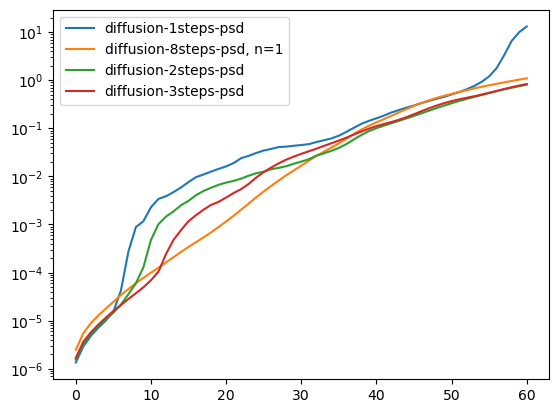

In [10]:
for k in results["eval_distances"].keys():
    print(np.mean([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(1)]))
    #print(np.mean([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(9)]))
    plt.plot([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(len(results["predictions"][k]))], label=k)


plt.yscale('log')
plt.legend()

a
a
a
a


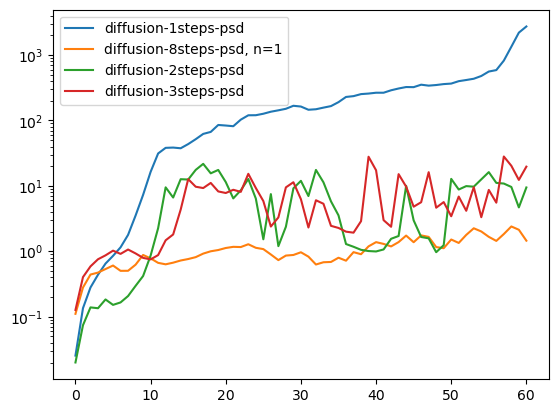

In [23]:
for k in results["eval_distances"].keys():
    print('a')
    plt.plot([fsd_torch_radial(results["predictions"][k][i].cpu(), results["data"][:,i+1].cpu()) for i in range(len(results["predictions"][k]))], label=k)


plt.yscale('log')
plt.legend()

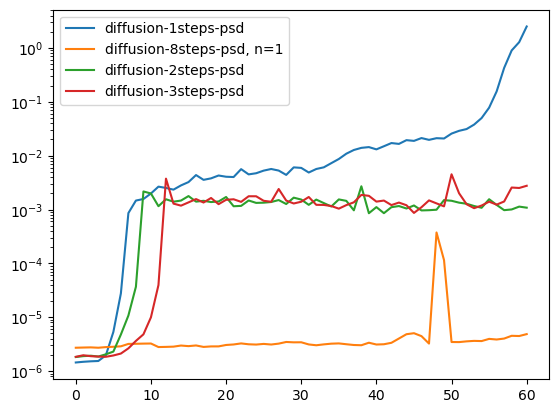

In [11]:
for k in results["eval_distances"].keys():
    #print(np.mean([torch.mean((results["predictions"][k][i] - results["data"][:,i+1])**2).cpu() for i in range(9)]))
    plt.plot([results["eval_distances"][k][i].cpu() for i in range(len(results["predictions"][k]))], label=k)


plt.yscale('log')
plt.legend()

In [14]:
from scipy.stats import pearsonr

def correlation(qa, qb):
    return pearsonr(qa.ravel(), qb.ravel())[0]

def vorticity(x: torch.Tensor) -> torch.Tensor:
    """Computes the vorticity of a 2D vector field."""
    *batch, _, h, w = x.shape
    y = x.reshape(-1, 2, h, w)
    # Pad for circular boundary conditions
    y = torch.nn.functional.pad(y, pad=(1, 1, 1, 1), mode='circular')

    du, = torch.gradient(y[:, 0], dim=-1)
    dv, = torch.gradient(y[:, 1], dim=-2)

    # Crop back to original size
    vort = (dv - du)[:, 1:-1, 1:-1]
    # Reshape to original batch dimensions
    vort = vort.reshape(*batch, h, w)
    return vort

In [15]:
import numpy as np
import torch

def evaluate_trajectory_vorticity(results, threshold=0.8):
    """
    Performs autoregressive rollout and computes vorticity correlation.
    Calculates time-until-failure stats including top/bottom 10% quantiles.
    """
    vorticities = {}

    for k in results["eval_distances"].keys():
        corrs = []
        
        # 1. Collect all correlations for this key
        # Outer loop is samples (N)
        for i in range(len(results["predictions"][k])):
            
            pred = results["predictions"][k][i].cpu()
            gt = results["data"][:, i+1].cpu()
            
            # Calculate vorticity
            # Ensure vorticity() and correlation() are defined in your scope
            pred_vort = vorticity(pred)
            gt_vort = vorticity(gt)
            
            # Compute correlation at each step (T)
            corrs_i = []
            for j in range(len(pred_vort)):
                p = pred_vort[j]
                g = gt_vort[j]
                corrs_i.append(correlation(p, g))

            corrs.append(np.array(corrs_i))
            
        # Shape is (N_samples, T_timesteps) because we appended time-series lists
        corrs = np.array(corrs).T
        N, T = corrs.shape
        
        # --- Aggregates per timestep ---
        # Axis 0 is samples. We want mean/std across samples for every timestep.
        mean_correlations = np.mean(corrs, axis=0) 
        std_per_timestep = np.std(corrs, axis=0)

        # --- Time Until Failure (Per Sample) ---
        # 1. Create mask where correlation drops below threshold
        below_threshold_mask = corrs < threshold

        # 2. Find first failure index
        # axis=1 searches along time. returns 0 if no failure found (or if failure is at 0)
        first_failure_indices = np.argmax(below_threshold_mask, axis=1)

        # 3. Check which actually failed
        has_failed = np.any(below_threshold_mask, axis=1)

        # 4. Calculate survival time
        # If failed: index + 1 (1-based count). If never failed: T
        times_under_threshold = np.where(
            has_failed, 
            first_failure_indices + 1, 
            T
        )
        
        # --- Global Mean ---
        mean_time_until_failure = np.mean(times_under_threshold)

        # --- Top/Bottom 10% Times ---
        # Sort times from lowest (worst) to highest (best)
        sorted_times = np.sort(times_under_threshold)
        
        # Calculate index for 10%
        # Use max(1, ...) to handle small batch sizes safely
        cutoff_idx = max(1, int(0.1 * N)) 
        
        # Worst 10% (Shortest survival times)
        worst_10_mean = np.mean(sorted_times[:cutoff_idx])
        
        # Top 10% (Longest survival times)
        # We take the slice from -cutoff_idx to the end
        top_10_mean = np.mean(sorted_times[-cutoff_idx:])

        vorticities[k] =  {
            'mean_correlations': mean_correlations, # Shape (T,)
            'std_per_timestep': std_per_timestep,   # Shape (T,)
            'time_under_threshold': mean_time_until_failure, # Scalar
            'time_under_threshold_worst_10': worst_10_mean,  # Scalar
            'time_under_threshold_best_10': top_10_mean,     # Scalar
        }

    return vorticities

In [16]:
vorticities = evaluate_trajectory_vorticity(results)

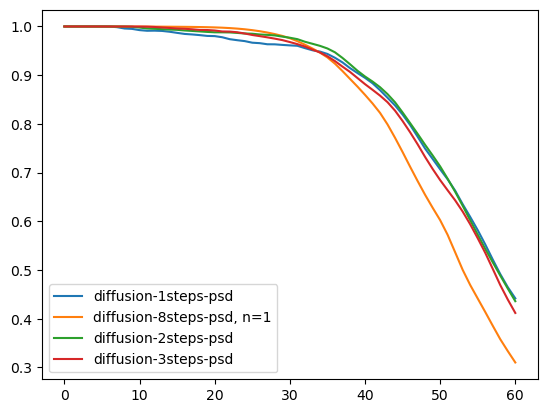

In [17]:
for k in vorticities:
    plt.plot(vorticities[k]['mean_correlations'], label=k)

plt.legend()

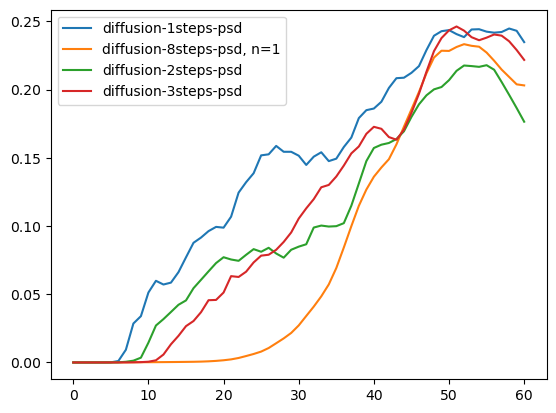

In [18]:
for k in vorticities:
    plt.plot(vorticities[k]['std_per_timestep'], label=k)

plt.legend()

In [19]:
for k in vorticities:
    print(k, vorticities[k]['time_under_threshold'])

diffusion-1steps-psd 49.7
diffusion-8steps-psd, n=1 46.38
diffusion-2steps-psd 49.36
diffusion-3steps-psd 49.16


In [20]:
for k in vorticities:
    print(k, vorticities[k]['time_under_threshold_worst_10'])

diffusion-1steps-psd 29.4
diffusion-8steps-psd, n=1 35.8
diffusion-2steps-psd 32.2
diffusion-3steps-psd 31.2


In [22]:
for k in vorticities:
    print(k, vorticities[k]['time_under_threshold_best_10'])

diffusion-1steps-psd 60.8
diffusion-8steps-psd, n=1 58.0
diffusion-2steps-psd 59.2
diffusion-3steps-psd 60.2


In [33]:
import torch
import matplotlib.pyplot as plt

def compute_checkpoint_metrics(
    checkpoint_dir_run108,
    checkpoint_dir_run109,
    eval_model,
    traj_loader,
    device,
    checkpoints=[901, 921, 941, 961, 981, "best"],
    rollout_steps=10,
):
    """
    Computes evaluation metrics for multiple checkpoints.

    Returns:
        tuple: (plot_data, results_all)
            - plot_data: List of dicts containing x, y, metric, label info for plotting.
            - results_all: Dict containing full raw evaluation outputs.
    """

    def load_diffusion_model(checkpoint_path):
        """Helper to load and return a DiffusionModel from a checkpoint."""
        # Note: Assuming DiffusionModel class is available in the global scope
        model = DiffusionModel(
            **{
                "dimension": 2,
                "dataSize": [64, 64],
                "condChannels": 2,
                "diffSchedule": "cubic",
                "diffSteps": 100,
                "inferenceSamplingMode": "ddpm",
                "inferenceConditioningIntegration": "clean",
                "diffCondIntegration": "clean",
                "inferenceInitialSampling": "random",
                "x0_estimate_type": "mean",
            }
        ).to(device)

        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint)
        return model

    results_all = {}
    plot_data = []

    for ckpt in checkpoints:
        # Build checkpoint paths
        ckpt108 = (
            f"{checkpoint_dir_run108}/epoch_{ckpt}.pth"
            if ckpt != "best"
            else f"{checkpoint_dir_run108}/best_model.pth"
        )
        ckpt109 = (
            f"{checkpoint_dir_run109}/epoch_{ckpt}.pth"
            if ckpt != "best"
            else f"{checkpoint_dir_run109}/best_model.pth"
        )

        print(f"\n🧩 Evaluating checkpoints: {ckpt108} and {ckpt109}")

        # Load models
        m1 = load_diffusion_model(ckpt108)
        m2 = load_diffusion_model(ckpt109)

        # Evaluate
        # Note: Assuming evaluate_models is available in scope
        results = evaluate_models(
            {"diffusion-1step-psd": m1, "diffusion-2steps-psd": m2},
            eval_model,
            traj_loader,
            device,
            rollout_steps=rollout_steps,
        )

        results_all[ckpt] = results

        # Process metrics for this checkpoint
        model_configs = [
            ("diffusion-1step-psd", "tab:blue", "o"),
            ("diffusion-2steps-psd", "tab:orange", "x"),
        ]

        for model_key, color, marker in model_configs:
            # 1. Compute MSE trajectory
            # predictions shape assumed: [steps, batch, ...] 
            # data shape assumed: [batch, steps, ...]
            mse_trajectory = [
                torch.mean(
                    (results["predictions"][model_key][t] - results["data"][:, t + 1]) ** 2
                ).cpu().item()
                for t in range(rollout_steps)
            ]

            x_val = mse_trajectory[0]   # Error at t=0
            y_val = mse_trajectory[-1]  # Error at t=end

            # 2. Compute Metric (Dist last / Dist first)
            dist = torch.tensor(results["eval_distances"][model_key])
            metric_val = (dist[-1] / dist[0]).cpu().item()

            # Store lightweight data for plotting
            plot_data.append({
                "ckpt": ckpt,
                "model_key": model_key,
                "x_val": x_val,
                "y_val": y_val,
                "metric_val": metric_val,
                "color": color,
                "marker": marker
            })

    return plot_data, results_all


def plot_checkpoint_metrics(plot_data, rollout_steps):
    """
    Visualizes the processed checkpoint metrics.

    Args:
        plot_data (list): Output from compute_checkpoint_metrics.
        rollout_steps (int): Used for axis labeling.
    """
    plt.figure(figsize=(8, 6))

    for item in plot_data:
        label = f"{item['model_key']} @ {item['ckpt']}"
        
        plt.scatter(
            item['x_val'], 
            item['y_val'], 
            color=item['color'], 
            marker=item['marker'], 
            label=label
        )
        
        plt.text(
            item['x_val'],
            item['y_val'],
            f"{item['metric_val']:.3f}",
            color=item['color'],
            fontsize=9,
            ha="left",
            va="bottom",
        )

    plt.xlabel("Error at t=0")
    plt.ylabel(f"Error at t={rollout_steps}")
    plt.xscale('log')
    plt.title(f"Error evolution (t=0 vs t={rollout_steps}) across checkpoints")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [30]:
results_all = compute_checkpoint_metrics(
    '/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_188',
    '/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_244',
    m_eval_1,
    traj_loader,
    device="cuda",
    checkpoints=[21, 61, 101, 141, 181],
    rollout_steps=20
    )


🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_188/epoch_21.pth and /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_244/epoch_21.pth
Input shape: torch.Size([100, 64, 2, 64, 64])

🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_188/epoch_61.pth and /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_244/epoch_61.pth
Input shape: torch.Size([100, 64, 2, 64, 64])

🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_188/epoch_101.pth and /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_244/epoch_101.pth
Input shape: torch.Size([100, 64, 2, 64, 64])

🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_188/epoch_141.pth and /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_244/epoch_141.pth
Input shape: torch.Size([100, 64, 2, 64, 64])

🧩 Evaluating checkpoints: /mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_188

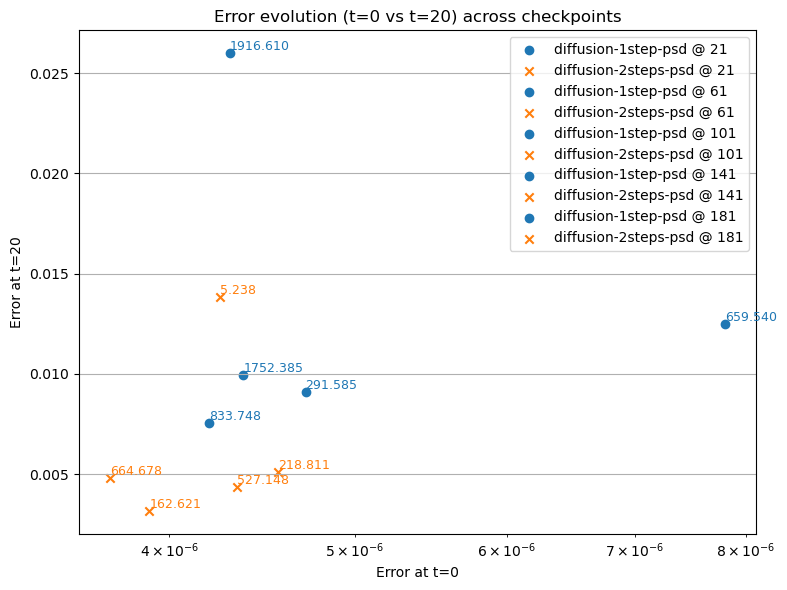

In [34]:
plot_checkpoint_metrics(results_all[0], 20)